In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import xgcm
import matplotlib.pyplot as plt
from load_example_ecco_grid import * 
import xbudget
from xbudget.llc90 import * 
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xarray: 2026.2.0
xgcm: 0.9.0


In [3]:
def zero_top_layer(ds, varname = "", zdim = "k_l"):
    return xr.where(ds[f"{zdim}"] != ds[f"{zdim}"].isel({f"{zdim}":0}),ds[varname].copy(),0.0,)
def make_flux_3d(ds, varname = "", zdim = "k"):
    k  = ds[f"{zdim}"]
    return xr.where(k == k.isel({f"{zdim}":0}), ds[varname].copy().expand_dims({f"{zdim}":k}),0.0,)

def plot_interpolated_ecco(fig, ax, ds, vmin=0, vmax=30, cmap="coolwarm"):
    target_lon = np.arange(-180, 180, 1)
    target_lat = np.arange(-90, 90, 1)
    lon_grid, lat_grid = np.meshgrid(target_lon, target_lat)
    
    # 2. Flatten everything (ignoring NaNs)
    points = np.column_stack((ds.XC.values.ravel(), ds.YC.values.ravel()))
    values = ds.values.ravel()
    
    # 3. Snap to the regular grid
    interpolated_data = griddata(points, values, (lon_grid, lat_grid), method='nearest')
    
    # 4. Plot the unified map
    cb = ax.pcolormesh(lon_grid, lat_grid, interpolated_data, 
                       vmin=vmin, vmax=vmax, cmap=cmap)
    
    return cb

In [4]:
ecco_budget = xr.open_dataset("/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/example-ECCOV4r4-budget-terms/data/ECCO_budget_terms.nc", engine = "netcdf4")
dt = ecco_budget["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})

ecco_budget = ecco_budget.assign_coords(
    {"dt":("time", dt.dt.total_seconds().values), 
    "volcello": (ecco_budget["drF"] * ecco_budget["hFacC"]) * ecco_budget["rA"]
    }
)

In [5]:
#heat flux terms
ecco_budget["geothermal_heat_flux_convergence"] = calc_llc90_geothermal_heatflux_tendency(ecco_budget) 
ecco_budget["pen_boundary_forcing_heat_tendency"] = llc90_penetrative_heat_flux_tendency(ecco_budget)
ecco_budget["nonpen_boundary_forcing_heat_tendency"] = llc90_nonpenetrative_heat_flux_tendency(ecco_budget)
ecco_budget["boundary_forcing_heat_tendency"] = ecco_budget["pen_boundary_forcing_heat_tendency"] + ecco_budget["nonpen_boundary_forcing_heat_tendency"]

# salt flux terms
SFLUX = ecco_budget["SFLUX"].assign_coords(k=0).expand_dims(dim='k',axis=1) #sea ice salt exchange
ecco_budget["boundary_forcing_salt_tendency"] = xr.concat([SFLUX+ecco_budget["oceSPtnd"],ecco_budget["oceSPtnd"].isel(k=slice(1,None))], dim='k') # add  salt plume tendency (g/m^2/s)

# volume terms
ecco_budget["WVELMASS_interior"] = zero_top_layer(ecco_budget, varname = "WVELMASS", zdim = "k_l")
ecco_budget["oceFWflx_3d"] = make_flux_3d(ecco_budget, varname = "oceFWflx", zdim = "k")

ecco_budget = ecco_budget.chunk({"k_l":-1, "tile":-1, "time_bounds":-1, "time":-1})

ecco_budget = ecco_budget.fillna(0.0)

#to-do: need to add a chunking line in the difference and convergence sections of the code 

geothermalFlux not found, retrieving from GitHub...
load_binary_array: loading file /var/folders/vt/sjvxnnwn7y51hx1c814wrxn80000gn/T/tmpg_v1_p8p/geothermalFlux.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4


In [6]:
grid = construct_grid(ecco_budget)
xbudget_dict = xbudget.load_yaml("ECCOV4r4_extensive.yaml").copy()
xbudget.collect_budgets(grid, xbudget_dict)
simple_budgets = xbudget.aggregate(xbudget_dict)
simple_budgets

/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:359: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:359: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:359: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:359: UserWarni

{'mass': {'lambda': 'density',
  'thickness': 'thkcello',
  'lhs': {'Eulerian_tendency': 'mass_lhs_sum_Eulerian_tendency'},
  'rhs': {'advection': 'mass_rhs_sum_advection',
   'surface_exchange_flux': 'mass_rhs_sum_surface_exchange_flux'}},
 'heat': {'lambda': 'THETA',
  'lhs': {'Eulerian_tendency': 'heat_lhs_sum_Eulerian_tendency'},
  'rhs': {'advection': 'heat_rhs_sum_advection',
   'diffusion': 'heat_rhs_sum_diffusion',
   'surface_exchange_flux': 'heat_rhs_sum_surface_exchange_flux',
   'bottom_flux': 'heat_rhs_sum_bottom_flux'}},
 'salt': {'lambda': 'SALT',
  'lhs': {'Eulerian_tendency': 'salt_lhs_sum_Eulerian_tendency'},
  'rhs': {'advection': 'salt_rhs_sum_advection',
   'diffusion': 'salt_rhs_sum_diffusion',
   'surface_exchange_flux': 'salt_rhs_sum_surface_exchange_flux'}}}

### Volume budgets

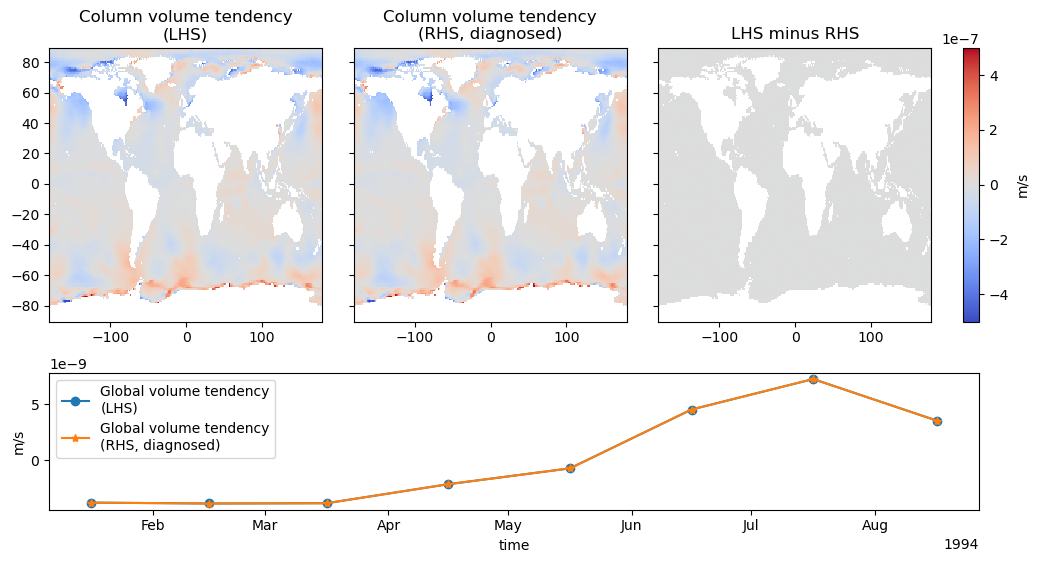

In [7]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

lhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "mass_lhs")["var"]] / (area * 1029.0)).sum("k") #convert from kg/s to m^3 / s/ m^2 <-> m/s
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "mass_rhs_sum")["var"]] / (area * 1029.0)).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

tendency_difference = lhs_tendency - rhs_tendency

vmin, vmax = -5e-7, 5e-7
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=0), vmin=vmin, vmax=vmax); ax0.set_title("Column volume tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=0), vmin=vmin, vmax=vmax); ax1.set_title("Column volume tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=0), vmin=vmin, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "m/s")

((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global volume tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global volume tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("m/s")
ax_bottom.legend()

### Heat budgets

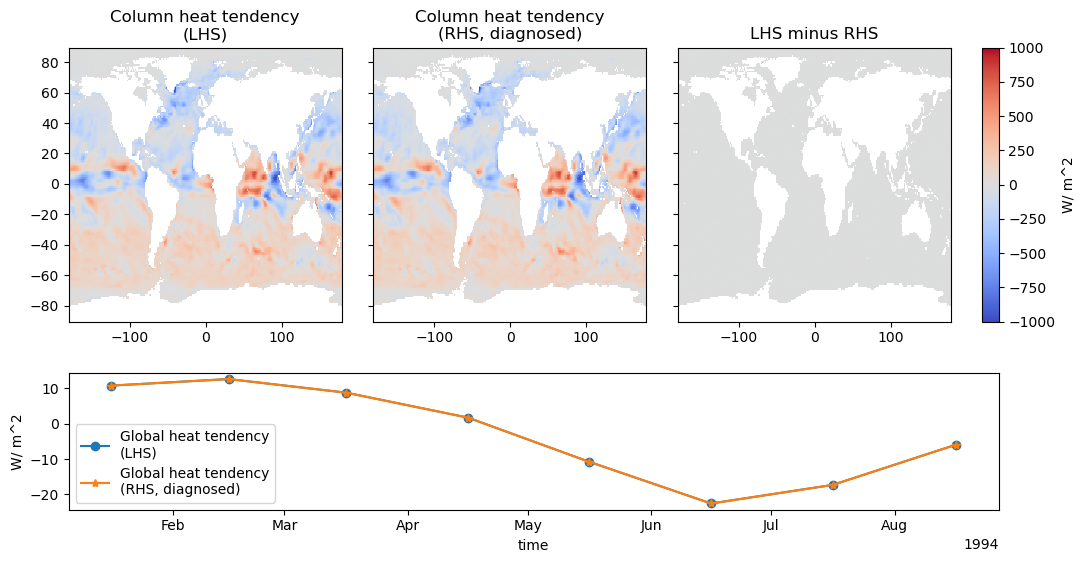

In [11]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

lhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "heat_lhs")['var']] / (area)).sum("k") #convert from J/s to W/m^2
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "heat_rhs")['var']] / (area)).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

tendency_difference = lhs_tendency - rhs_tendency

vmax = 1000
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax0.set_title("Column heat tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax1.set_title("Column heat tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=0), vmin=-vmax, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "W/ m^2")

((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global heat tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global heat tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("W/ m^2")
ax_bottom.legend()

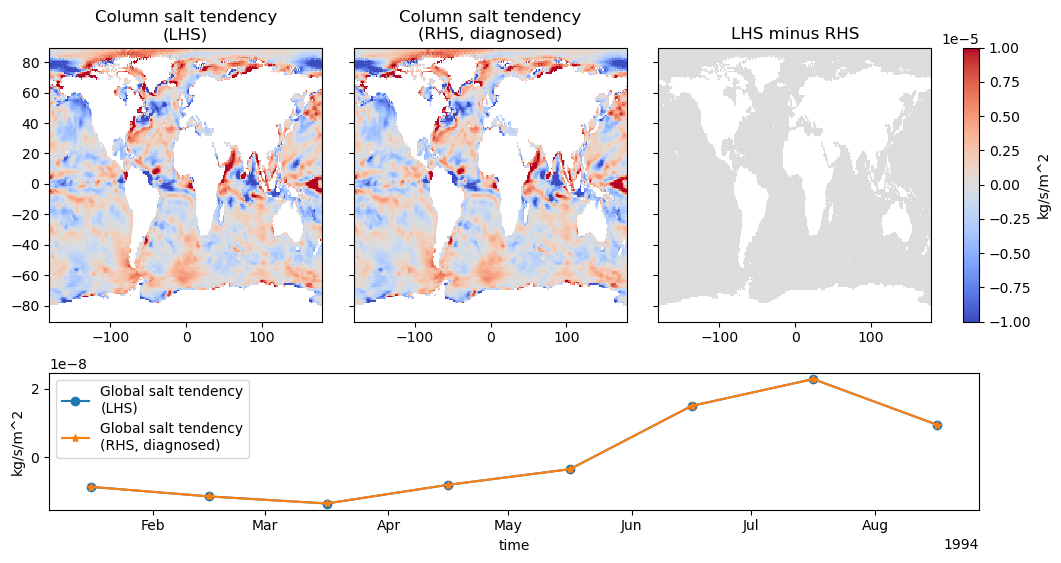

In [17]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

lhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "salt_lhs")['var']] / (area)).sum("k") #convert from kg/s to kg/s/m^2
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "salt_rhs")['var']] / (area)).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

tendency_difference = lhs_tendency - rhs_tendency

vmax = 1e-5
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax0.set_title("Column salt tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax1.set_title("Column salt tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=0), vmin=-vmax, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "kg/s/m^2")

((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global salt tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global salt tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("kg/s/m^2")
ax_bottom.legend()